In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, LongType, StringType, ArrayType
from pyspark.sql.functions import explode, lower, col, collect_set

# In cluster use the HDFS path prefix
path_prefix = "hdfs:///projects/BDA-12/"
# In local use the local path prefix
# path_prefix = "" 

spark = SparkSession.builder \
    .appName("IngredientFrequency") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Strict schema
ingredients_schema = StructType([
    StructField('fdc_id', LongType(), False),
    StructField('description', StringType(), True),
    StructField('all_ingredients', ArrayType(StringType()), True)
])

df = spark.read.schema(ingredients_schema).parquet(
    f'{path_prefix}/output/ingredients_nutrional_profiles/'
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/15 17:52:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Explode ingredients and normalize
from pyspark.sql.functions import trim, regexp_replace
pattern = r'[\(\)\"\*\[\]\{\}\.,:;\'\-&]' #pattern
exploded = df.select('fdc_id', 'description', explode('all_ingredients').alias('ingredient'))
exploded = exploded.withColumn('ingredient_norm', trim(lower(regexp_replace(col('ingredient'), pattern, ''))))
# Remove duplicates: ingredient counted once per food
unique_ingredients = exploded.groupBy('fdc_id', 'description').agg(collect_set('ingredient_norm').alias('ingredients_set'))
exploded_unique = unique_ingredients.select('fdc_id', 'description', explode('ingredients_set').alias('ingredient_norm'))

In [8]:
from pyspark.sql.functions import count
if "hdfs" not in path_prefix:
    import os
    os.makedirs(f'{path_prefix}/output/ingredient_frequency', exist_ok=True)
ingredient_counts = exploded_unique.groupBy('ingredient_norm').agg(
    count('fdc_id').alias('food_count'),
    collect_set('description').alias('examples')
)
ingredient_counts = ingredient_counts.orderBy(col('food_count').desc())
ingredient_counts.cache()
# Top and rare as Spark DataFrames (no pandas)
top10_df = ingredient_counts.limit(10)
rare10_df = ingredient_counts.orderBy(col('food_count').asc()).limit(10)
# Display results using Spark's show()
top10_df.show(5)
rare10_df.show(5)
# Save all ingredient frequencies to CSV directory using Spark (creates a folder)
ingredient_counts.coalesce(1).write.mode("overwrite").option("header", "true").parquet(f'{path_prefix}/output/ingredient_frequency')

26/01/15 18:01:50 WARN CacheManager: Asked to cache already cached data.


+---------------+----------+--------------------+
|ingredient_norm|food_count|            examples|
+---------------+----------+--------------------+
|           salt|   1024819|[WEGMANS, KETTLE ...|
|          sugar|    771841|[CHOCOLATE MINT F...|
|          water|    708673|[DIET CRANBERRY B...|
|    citric acid|    446555|[DIET CRANBERRY B...|
|     folic acid|    324579|[ICED HONEY BUN W...|
+---------------+----------+--------------------+
only showing top 5 rows

+--------------------+----------+--------------------+
|     ingredient_norm|food_count|            examples|
+--------------------+----------+--------------------+
|            % garlic|         1|[POTATO AND LEEK ...|
|           01% basil|         1|       [COCONUT OIL]|
|/or safflower ill...|         1|[WHITE CREME & PE...|
|/or safflower oil...|         1|[WHITE CREME & PE...|
|000da processed w...|         1|[BROWNIE BLAST FR...|
+--------------------+----------+--------------------+
only showing top 5 rows



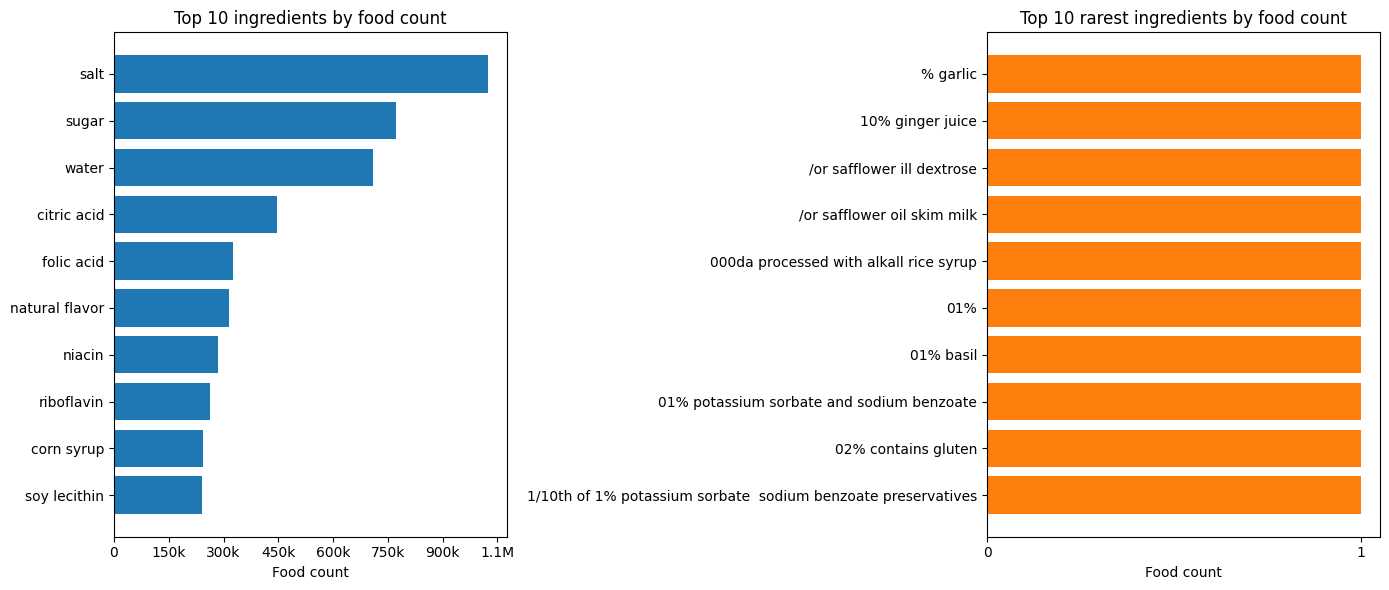

26/01/15 18:06:14 ERROR StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
26/01/15 18:06:14 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291)
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981)
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint$$anonfun$receive$1.applyOrElse(StandaloneAppClient.scala:170)
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:115)
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213)
	at org.apache.spark.rpc.netty.Inbox.proce

In [11]:
# Plot top 10 and top 10 rarest ingredients using matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

# Convert small Spark DataFrames to pandas for plotting
top10_pd = top10_df.select('ingredient_norm','food_count').toPandas()
rare10_pd = rare10_df.select('ingredient_norm','food_count').toPandas()

# Ensure counts are integers so x-axis shows whole numbers
top10_pd['food_count'] = top10_pd['food_count'].astype(int)
rare10_pd['food_count'] = rare10_pd['food_count'].astype(int)

# Sort for nicer appearance (most common descending, rarest ascending)
top10_pd = top10_pd.sort_values('food_count', ascending=False)
rare10_pd = rare10_pd.sort_values('food_count', ascending=True)

# Formatter to show k and M suffixes
def human_format(x, pos=None):
    try:
        x = float(x)
    except Exception:
        return str(x)
    if x >= 1_000_000:
        val = x / 1_000_000.0
        return f'{val:.1f}M' if val < 10 else f'{int(val)}M'
    if x >= 1_000:
        val = x / 1_000.0
        return f'{val:.1f}k' if val < 10 else f'{int(val)}k'
    return str(int(x))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 (most common)
axes[0].barh(top10_pd['ingredient_norm'], top10_pd['food_count'], color='tab:blue')
axes[0].set_title('Top 10 ingredients by food count')
axes[0].set_xlabel('Food count')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].xaxis.set_major_formatter(FuncFormatter(human_format))
axes[0].invert_yaxis()

# Rarest 10
axes[1].barh(rare10_pd['ingredient_norm'], rare10_pd['food_count'], color='tab:orange')
axes[1].set_title('Top 10 rarest ingredients by food count')
axes[1].set_xlabel('Food count')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].xaxis.set_major_formatter(FuncFormatter(human_format))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()